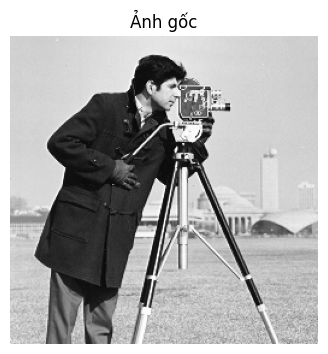

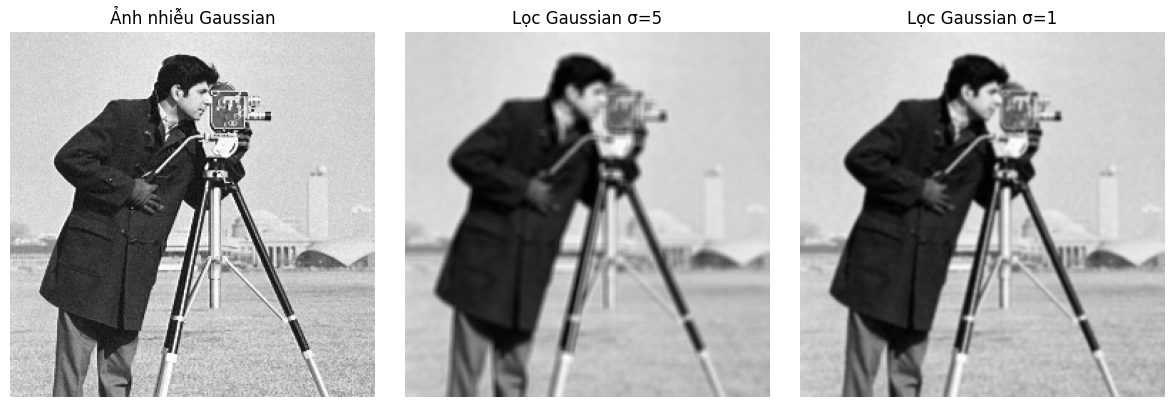

Kích thước ảnh gốc: (256, 256)
Kích thước ảnh nhiễu: (256, 256)
Kích thước ảnh sau lọc sigma = 5: (256, 256)
Kích thước ảnh sau lọc sigma = 1: (256, 256)
Kiểu dữ liệu ảnh gốc: uint8
Kiểu dữ liệu ảnh nhiễu: uint8
Kiểu dữ liệu ảnh sau lọc sigma = 5: uint8
Kiểu dữ liệu ảnh sau lọc sigma = 1: uint8


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: KHỬ NHIỄU CỘNG BẰNG BỘ LỌC GAUSSIAN
# Chương/Mục liên quan: Chương 4 - Lọc ảnh trong miền không gian
# Ví dụ: 4.3.1.1 - Khử nhiễu cộng
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán khử nhiễu cộng trên ảnh xám.
# - Bổ sung nhiễu Gaussian vào ảnh đầu vào.
# - Sử dụng bộ lọc Gaussian để làm trơn ảnh nhiễu.
# - So sánh ảnh sau lọc khi thay đổi tham số sigma.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh bị nhiễu Gaussian.
# 2. Quan sát được ảnh sau khi lọc Gaussian với các giá trị sigma khác nhau.
# 3. Hiểu rằng sigma điều khiển mức độ làm trơn của bộ lọc Gaussian.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman.png từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh nhiễu Gaussian
# - Ảnh sau lọc Gaussian với sigma = 5
# - Ảnh sau lọc Gaussian với sigma = 1

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

I = read_gitlab_image(image_uri)

if I is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(I, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Bước 1: Bổ sung nhiễu Gaussian có trung bình 0 và độ lệch chuẩn sigma = 5
# Dòng code này minh họa mô hình nhiễu cộng:
# In = I + noise
noise = np.random.normal(0, 5, I.shape)
In = np.clip(I + noise, 0, 255).astype(np.uint8)

# Bước 2: Lọc Gaussian với sigma = 5
# Dòng code này tương ứng với thao tác làm trơn ảnh bằng bộ lọc Gaussian
Ig5 = cv2.GaussianBlur(In, (5, 5), 5)

# Bước 3: Lọc Gaussian với sigma = 1
# Thay đổi sigma để quan sát ảnh hưởng của mức độ làm trơn
Ig1 = cv2.GaussianBlur(In, (5, 5), 1)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(In, cmap='gray')
plt.title('Ảnh nhiễu Gaussian')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Ig5, cmap='gray')
plt.title('Lọc Gaussian σ=5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Ig1, cmap='gray')
plt.title('Lọc Gaussian σ=1')
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", I.shape)
print("Kích thước ảnh nhiễu:", In.shape)
print("Kích thước ảnh sau lọc sigma = 5:", Ig5.shape)
print("Kích thước ảnh sau lọc sigma = 1:", Ig1.shape)

print("Kiểu dữ liệu ảnh gốc:", I.dtype)
print("Kiểu dữ liệu ảnh nhiễu:", In.dtype)
print("Kiểu dữ liệu ảnh sau lọc sigma = 5:", Ig5.dtype)
print("Kiểu dữ liệu ảnh sau lọc sigma = 1:", Ig1.dtype)

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi độ lệch chuẩn của nhiễu trong dòng:
#    noise = np.random.normal(0, 5, I.shape)
#    Ví dụ: đổi 5 thành 10 hoặc 20 để tăng mức nhiễu.

# 2. Thay đổi sigma của bộ lọc Gaussian trong dòng:
#    Ig5 = cv2.GaussianBlur(In, (5, 5), 5)
#    Ví dụ: đổi sigma từ 5 sang 2, 7 hoặc 10.

# 3. Thay đổi kích thước cửa sổ lọc trong dòng:
#    cv2.GaussianBlur(In, (5, 5), sigma)
#    Ví dụ: đổi (5, 5) thành (3, 3), (7, 7) hoặc (9, 9).